In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
import pandas as pd
import seaborn as sns
import torch
import numpy as np
import scipy
import solvers
import sde
import gaussians

torch.manual_seed(42)

In [2]:
# SDE Setup
beta_min = 0.1
beta_max = 20
sde = sde.LinearVariancePreservingSDE(beta_min, beta_max)

In [3]:
# Gaussian & score setup
gaussian1 = gaussians.Gaussian(
    mu=0,
    sigma=1,
    weight=1/8
)
gaussian2 = gaussians.Gaussian(
    mu=-50,
    sigma=3,
    weight=2/8
)

gaussian3 = gaussians.Gaussian(
    mu=15,
    sigma=5,
    weight=1/2
)

gaussian4 = gaussians.Gaussian(
    mu=-20,
    sigma=10,
    weight= 1/8
)

multi_gaussian = gaussians.MultiGaussian((gaussian1, gaussian2, gaussian3, gaussian4), sde)
score_func = multi_gaussian.get_score_function()

# Create reverse sde based on score function
reverse_sde = sde.get_reverse_sde(score_func)

Text(0.5, 1.0, 'Samples from distribution')

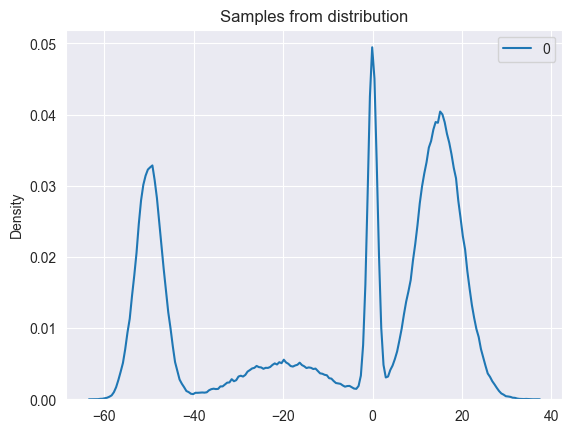

In [4]:
# Sampling
n_samples = 100000
samples = multi_gaussian.sample(n_samples).unsqueeze(-1)
x_ground_truth = torch.sort(samples)[0]

plt.figure()
sns.kdeplot(x_ground_truth, bw_adjust=0.1)
plt.title("Samples from distribution")
plt.xlabel("x")

Text(0.5, 1.0, 'Data before transformation')

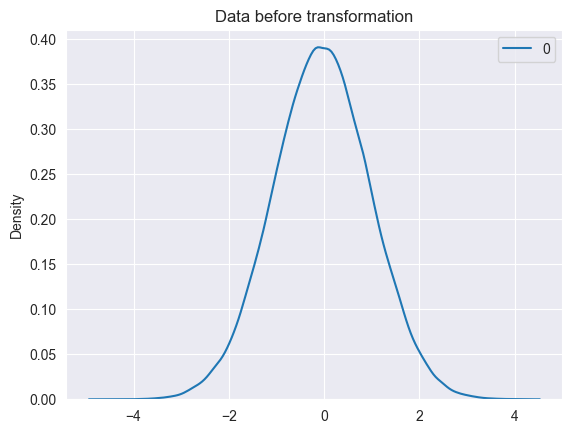

In [5]:
# Sample x from the marginal
x_start = sde.sample(x_ground_truth, torch.Tensor([1]))

# Plot initial data
plt.figure()
sns.kdeplot(x_start)
plt.title("Data before transformation")
plt.xlabel("x")

In [19]:
# Euler Marayuma setup
multi_gaussian.reset_nfe()

x_em_log = []
t_em_log = []

def log_em(x: torch.Tensor, t: torch.Tensor):
    # Track 4 x from the batch
    x_em_log.append(x[0:4, :].clone())
    t_em_log.append(t.clone())

n_steps = 67
discretisation = torch.linspace(1, 0, n_steps)
em_solver = solvers.EulerMarayumaSolver(reverse_sde, discretisation)

x_em = em_solver.solve(x_start.clone(), callback=log_em)

# Logging
x_em_log = np.array(x_em_log)[:, :, 0]
t_em_log = np.array(t_em_log)

# Baseline PDF
interval = torch.linspace(torch.min(x_em) - 3, torch.max(x_em) + 3, 10000).unsqueeze(-1)
verification = multi_gaussian(interval)

Text(0.5, 0, 'x')

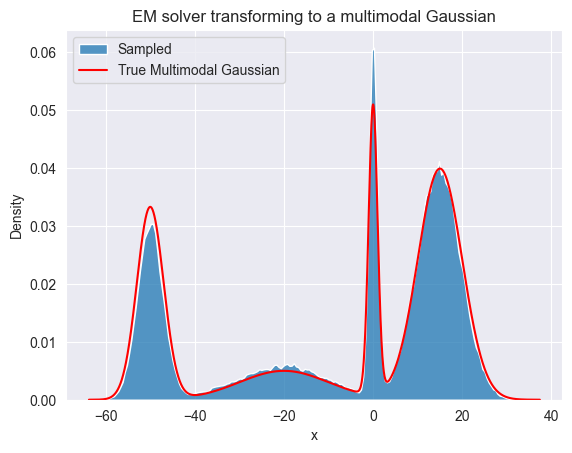

In [20]:
# Euler Marayuma Plots
plt.figure()
sns.kdeplot(x_em, label="Sampled", multiple="stack", bw_adjust=0.1)
plt.plot(interval, verification, c="r", label="True Multimodal Gaussian")
plt.legend()
plt.title("EM solver transforming to a multimodal Gaussian")
plt.xlabel("x")

In [21]:
# Euler Marayuma Evaluation
nfe_em_per_sample = multi_gaussian.nfe / n_samples
wasserstein_distance_em = scipy.stats.wasserstein_distance(x_ground_truth[:, 0], torch.sort(x_em)[0][:, 0])

print(f"NFE per sample for Euler-Marayuma sampler: {nfe_em_per_sample}")
print(f"Wasserstein distance for Euler-Marayuma sampler: {wasserstein_distance_em}")

NFE per sample for Euler-Marayuma sampler: 58.0
Wasserstein distance for Euler-Marayuma sampler: 1.2447742579260277


In [9]:
# PI solver setup
reverse_sde.reset_nfe()
torch.manual_seed(42)

x_pi_log = []
t_pi_log = []

def log_pi(x: torch.Tensor, t: torch.Tensor):
    # Track 4 x from the batch
    x_pi_log.append(x[0:4, :].clone())
    t_pi_log.append(t[0:4, :].clone())


pi_solver = solvers.PISolver(
    reverse_sde,
    ki=0.101, 
    kp=0.09, 
    tau_a=0.42668694, 
    tau_r=0.7,
    alpha=0.8,
    h_start=0.01,
    max_decrease=0.7,
    max_increase=1.20
)

x_pi = pi_solver.solve(x_start.clone(), callback=log_pi)

# Logging
x_pi_log = np.array(x_pi_log)[:, :, 0]
t_pi_log = np.array(t_pi_log)[:, :, 0]

# Baseline PDF
interval = torch.linspace(torch.min(x_pi) - 3, torch.max(x_pi) + 3, 10000).reshape((10000, 1))
verification = multi_gaussian(interval)

tensor(0.0004)


Text(0.5, 1.0, 'PI adaptive solver transforming to a multimodal Gaussian')

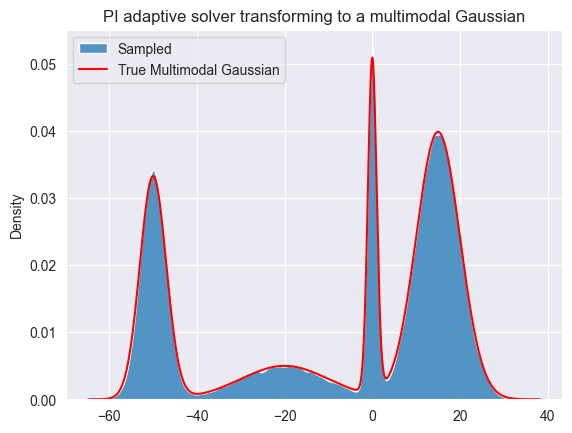

In [10]:
# PI Plots
plt.figure()
sns.kdeplot(x_pi, label="Sampled", multiple="stack", bw_adjust=0.2)
plt.plot(interval, verification, c="r", label="True Multimodal Gaussian")
plt.legend()
plt.title("PI adaptive solver transforming to a multimodal Gaussian")
plt.xlabel("x")

In [11]:
# PI Evaluation
nfe_pi_per_sample = reverse_sde.nfe / x_start.shape[0]
wasserstein_distance_pi = scipy.stats.wasserstein_distance(x_ground_truth[:, 0], torch.sort(x_pi)[0][:, 0])

print(f"NFE per sample for PI sampler: {nfe_pi_per_sample}")
print(f"Wasserstein distance for PI sampler: {wasserstein_distance_pi}")

NFE per sample for PI sampler: 58.39264
Wasserstein distance for PI sampler: 0.16916435731822624


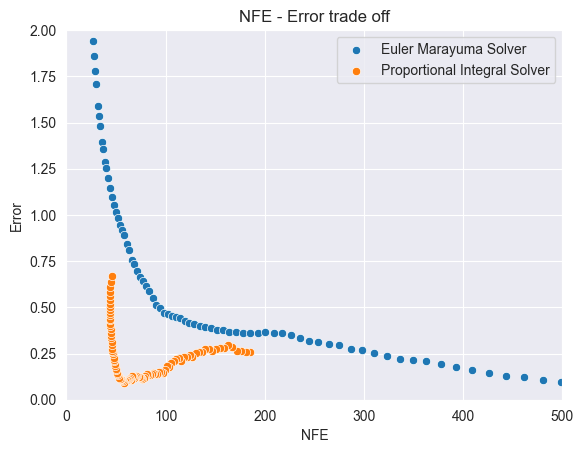

In [16]:
df = pd.read_csv("results/data-1775071551.0/data.csv")

plt.figure()
sns.scatterplot(df, x="em_nfe", y="em_error", label="Euler Marayuma Solver")
sns.scatterplot(df, x="pi_nfe", y="pi_error", label="Proportional Integral Solver")
plt.xlabel("NFE")
plt.xlim(0, 500)
plt.ylim(0, 2)
plt.ylabel("Error")
plt.title("NFE - Error trade off")
plt.legend()

In [13]:
# Create probability density colour map
x_interval = torch.linspace(torch.min(x_pi) - 3, torch.max(x_pi) + 3, 300)
t_interval = torch.linspace(0, 1, 200)
X, T = torch.meshgrid(x_interval, t_interval)
C = torch.zeros(X.shape)

for i, t in enumerate(t_interval):
    C[:, i] = multi_gaussian.multigaussian_at_t(t)(x_interval)

C:\Users\ellak\PycharmProjects\proportial-integral-generative-sde-solvers\Lib\site-packages\torch\functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


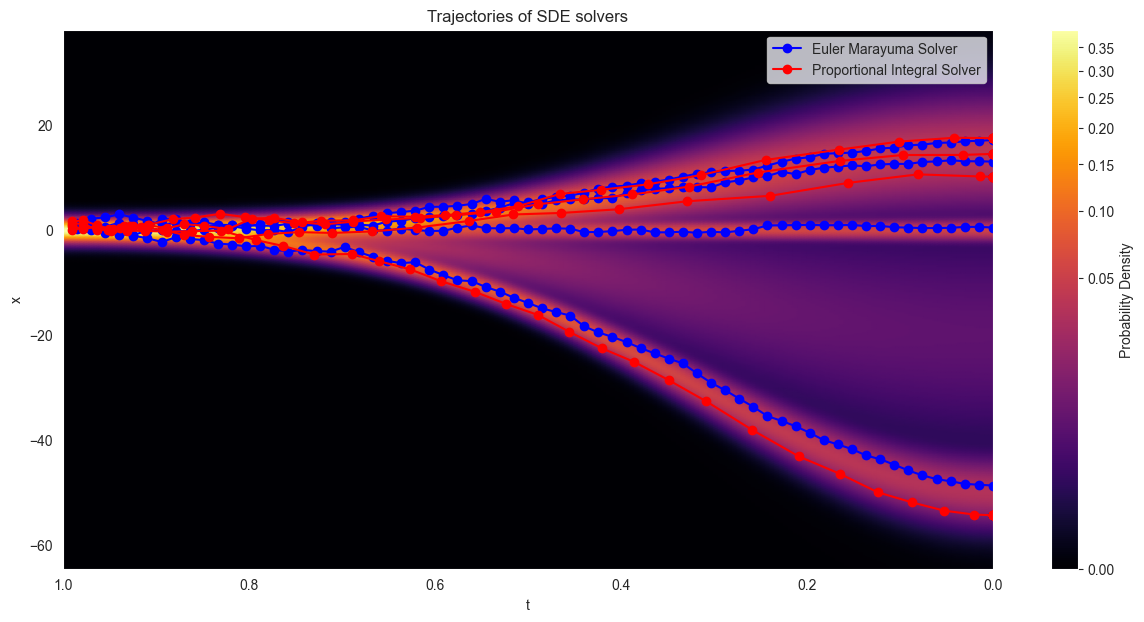

In [15]:
# Plotting
plt.figure(figsize=(15, 7))
plt.title("Trajectories of SDE solvers")

plt.xlim(1, 0)
mesh = plt.pcolormesh(T, X, C, cmap='inferno', shading='gouraud', norm=PowerNorm(gamma=0.3))
plt.colorbar(mesh,label='Probability Density')
for i in range(x_em_log.shape[1]):
    em = plt.plot(t_em_log, x_em_log[:, i], 'bo-')
em[0].set_label("Euler Marayuma Solver")

for i in range(x_pi_log.shape[1]):
    pi = plt.plot(t_pi_log[:, i], x_pi_log[:, i], 'ro-')
pi[0].set_label("Proportional Integral Solver")

plt.xlabel("t")
plt.ylabel("x")
plt.legend()
    
plt.show()